In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



FACMIC with BiomedCLIP — Federated Adaptive CLIP Model for Medical Image Classification
========================================================================================
Training clients  : client_0, client_1, client_2 \
Target domain     : client_3  (used UNLABELLED for LMMD domain adaptation) \
Test set          : client_3  (evaluated with labels after training)

Design follows the FACMIC paper (Wu et al., MICCAI):\
  • Frozen BiomedCLIP encoders \
  • Lightweight 5-layer feature-attention module per client\
  • Contrastive loss   Lcontr  \
  • LMMD domain-adaptation loss  LDA  — source = each training\
    client, target = client_3 images (no labels used)\
  • FedAVG weighted aggregation of attention parameters only  \
  • Dynamic per-image text prompts from llm_prompts_1.json;\
    class-level fallback when an image has no JSON entry

Requirements
------------
pip install open_clip_torch torch torchvision scikit-learn Pillow tqdm

In [3]:
!pip install open_clip_torch torch torchvision scikit-learn Pillow tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.4 MB/s eta 0:00:00


In [4]:
import argparse
import copy
import json
import os
import random
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

import open_clip

In [5]:
# ────────────────────────────────────────────────────────────────────────────
# Constants & reproducibility
# ────────────────────────────────────────────────────────────────────────────
CLASS_NAMES = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]
CLASS2IDX   = {c: i for i, c in enumerate(CLASS_NAMES)}

# Fallback prompts when an image path is absent from llm_prompts_1.json
FALLBACK_PROMPTS = {
    "glioma_tumor":     "brain MRI showing glioma tumor",
    "meningioma_tumor": "brain MRI showing meningioma tumor",
    "no_tumor":         "brain MRI showing no tumor",
    "pituitary_tumor":  "brain MRI showing pituitary tumor",
}


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [6]:
DATA_ROOT    = "/content/drive/MyDrive/FACMIC/data_augmented/BrainTumor"
PROMPTS_JSON = "/content/drive/MyDrive/FACMIC/llm_prompts_augmented_dataset.json"
OUTPUT_DIR   = "/content/drive/MyDrive/FACMIC/outputs_aug_data"

# ── Hyperparameters ──────────────────────────────────────────────────────────
ROUNDS       = 50
EPOCHS       = 1       # local epochs per round
BATCH_SIZE   = 32
LR           = 0.001
LMMD_LAMBDA  = 1.0
TEMPERATURE  = 0.07
EVAL_EVERY   = 2
SEED         = 42
# ────────────────────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [7]:
print("Loading BiomedCLIP ...")
biomedclip, _, preprocess = open_clip.create_model_and_transforms(
    "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
)
tokenizer = open_clip.get_tokenizer(
    "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
)
biomedclip = biomedclip.to(device).eval()
for p in biomedclip.parameters():
    p.requires_grad_(False)

# Infer feature dimension
with torch.no_grad():
    FEAT_DIM = biomedclip.encode_image(
        torch.zeros(1, 3, 224, 224, device=device)
    ).shape[-1]

print(f"BiomedCLIP loaded. Feature dim = {FEAT_DIM}")

Loading BiomedCLIP ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

BiomedCLIP loaded. Feature dim = 512


In [8]:
# ────────────────────────────────────────────────────────────────────────────
# BiomedCLIP loader
# ────────────────────────────────────────────────────────────────────────────
def load_biomedclip(device: torch.device):
    """
    Load Microsoft BiomedCLIP-PubMedBERT-256-vit_L_14 via open_clip.
    Returns (model, tokenizer, preprocess_val).
    All BiomedCLIP parameters are frozen — only the attention module trains.
    """
    model, _, preprocess_val = open_clip.create_model_and_transforms(
        "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
    )
    tokenizer = open_clip.get_tokenizer(
        "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
    )
    model = model.to(device).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    return model, tokenizer, preprocess_val

In [9]:
# ────────────────────────────────────────────────────────────────────────────
# Datasets
# ────────────────────────────────────────────────────────────────────────────
class BrainTumorDataset(Dataset):
    """
    Labelled dataset for a single client directory.

    Directory layout:
        <client_dir>/
            glioma_tumor/     *.jpg
            meningioma_tumor/ *.jpg
            no_tumor/         *.jpg
            pituitary_tumor/  *.jpg

    Parameters
    ----------
    client_dir : str   — path to the client folder
    prompts    : dict  — {json_path_key: prompt_string}
    transform          — open_clip / torchvision preprocessing
    split      : str   — 'train' | 'val' | 'test'  (80 / 10 / 10 per class)
    seed       : int
    """

    def __init__(
        self,
        client_dir: str,
        prompts: Dict[str, str],
        transform,
        split: str = "train",
        seed: int = 42,
    ):
        self.transform = transform
        self.prompts   = prompts
        # (abs_path, label_int, prompt_string)
        self.samples: List[Tuple[str, int, str]] = []

        for cls_name in CLASS_NAMES:
            cls_dir = Path(client_dir) / cls_name
            if not cls_dir.exists():
                continue
            files = sorted(
                p for p in cls_dir.iterdir()
                if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}
            )
            rng = random.Random(seed)
            rng.shuffle(files)
            n       = len(files)
            n_train = int(0.8 * n)
            n_val   = int(0.1 * n)
            if (split=='train') or (split=='val'):
                splits  = {
                    "train": files[:n_train],
                    "val":   files[n_train : n_train + n_val],
                    "test":  files[n_train + n_val :],
                }
            else:
                splits  = {
                    "test":  files
                }
            for fpath in splits[split]:
                prompt = self._resolve_prompt(fpath, cls_name)
                self.samples.append((str(fpath), CLASS2IDX[cls_name], prompt))

    def _resolve_prompt(self, fpath: Path, cls_name: str) -> str:
        """Match by filename; fall back to class-level prompt."""
        stem = fpath.name
        for key, val in self.prompts.items():
            if key.endswith(stem):
                return val
        return FALLBACK_PROMPTS[cls_name]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, prompt = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label, prompt


class UnlabelledDataset(Dataset):
    """
    Loads images from a directory WITHOUT labels.
    Used for client_3 as the LMMD target domain during training.
    Only the train split (50 %:50%) is used so the test images stay unseen.
    """

    def __init__(self, client_dir: str, transform, seed: int = 42):
        self.transform = transform
        self.paths: List[str] = []

        for cls_name in CLASS_NAMES:
            cls_dir = Path(client_dir) / cls_name
            if not cls_dir.exists():
                continue
            files = sorted(
                p for p in cls_dir.iterdir()
                if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}
            )
            rng = random.Random(seed)
            rng.shuffle(files)
            n_train = len(files)
            # Only train-split images — test images must stay completely unseen
            self.paths.extend(str(f) for f in files[:n_train])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)   # no label, no prompt



In [10]:
with open(PROMPTS_JSON) as f:
    prompts_dict = json.load(f)
print(f"Loaded {len(prompts_dict)} prompts.")

root              = Path(DATA_ROOT)
train_client_dirs = [str(root / f"client_{i}") for i in range(3)]
target_dir        = str(root / "client_3")

train_loaders, val_loaders = [], []
for cd in train_client_dirs:
    ds_tr = BrainTumorDataset(cd, prompts_dict, preprocess, "train", SEED)
    ds_va = BrainTumorDataset(cd, prompts_dict, preprocess, "val",   SEED)
    train_loaders.append(DataLoader(ds_tr, batch_size=BATCH_SIZE,
                                    shuffle=True,  num_workers=2,
                                    pin_memory=True, drop_last=True))
    val_loaders.append( DataLoader(ds_va, batch_size=BATCH_SIZE,
                                    shuffle=False, num_workers=2,
                                    pin_memory=True))

target_loader = DataLoader(
    UnlabelledDataset(target_dir, preprocess, SEED),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, drop_last=True,
)
test_loader = DataLoader(
    BrainTumorDataset(target_dir, prompts_dict, preprocess, "test", SEED),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True,
)

train_sizes = [len(dl.dataset) for dl in train_loaders]
print(f"Train sizes         : {train_sizes}")
print(f"Target (C3) unlabelled : {len(target_loader.dataset)}")
print(f"Test   (C3) labelled   : {len(test_loader.dataset)}")

Loaded 9335 prompts.
Train sizes         : [3703, 1064, 2380]
Target (C3) unlabelled : 394
Test   (C3) labelled   : 394


In [11]:
# ────────────────────────────────────────────────────────────────────────────
# Feature-Attention Module
# ────────────────────────────────────────────────────────────────────────────
class FeatureAttentionModule(nn.Module):
    """
    ai(·) : R^D -> [0,1]^D
    Linear -> BN -> LeakyReLU -> Linear -> Softmax
    Only this module is trained and communicated between clients and server.
    """

    def __init__(self, feat_dim: int):
        super().__init__()
        hidden = max(feat_dim // 4, 64)
        self.net = nn.Sequential(
            nn.Linear(feat_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(hidden, feat_dim),
            nn.Softmax(dim=-1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, D) -> masked features (B, D)"""
        return self.net(x) * x   # Hadamard product


In [12]:
# ────────────────────────────────────────────────────────────────────────────
# Contrastive loss
# ────────────────────────────────────────────────────────────────────────────
def contrastive_loss(
    img_feats: torch.Tensor,   # (B, D)
    txt_feats: torch.Tensor,   # (B, D)
    temperature: float = 0.07,
) -> torch.Tensor:
    """
    Symmetric cross-entropy over the B x B cosine-similarity matrix.
    Lcontr = -1/B sum_j 1/2 [log p_jj + log q_jj]
    """
    img_n  = F.normalize(img_feats, dim=-1)
    txt_n  = F.normalize(txt_feats, dim=-1)
    S      = img_n @ txt_n.T / temperature
    labels = torch.arange(S.size(0), device=S.device)
    return (F.cross_entropy(S, labels) + F.cross_entropy(S.T, labels)) / 2.0


In [13]:
# ────────────────────────────────────────────────────────────────────────────
# LMMD loss
# ────────────────────────────────────────────────────────────────────────────
def gaussian_kernel(
    x: torch.Tensor,
    y: torch.Tensor,
    bandwidth: Optional[float] = None,
) -> torch.Tensor:
    diff = x.unsqueeze(1) - y.unsqueeze(0)   # (n, m, D)
    sq   = (diff ** 2).sum(-1)               # (n, m)
    if bandwidth is None:
        bandwidth = sq.detach().median().clamp(min=1e-6).item()
    return torch.exp(-sq / (2.0 * bandwidth))

def lmmd_loss(
    src_feats:   torch.Tensor,   # (ns, D)  masked source (training client)
    tgt_feats:   torch.Tensor,   # (nt, D)  masked target (client_3, no labels)
    src_labels:  torch.Tensor,   # (ns,)    integer class labels
    tgt_probs:   torch.Tensor,   # (nt, K)  pseudo-label probabilities
    num_classes: int,
    bandwidth:   Optional[float] = None,
) -> torch.Tensor:
    """
    Local Maximum Mean Discrepancy.
    Source Ds = current training client (labelled).
    Target Dt = client_3 images (unlabelled, pseudo-labelled via Eq. 3).
    """
    K_ss = gaussian_kernel(src_feats, src_feats, bandwidth)
    K_tt = gaussian_kernel(tgt_feats, tgt_feats, bandwidth)
    K_st = gaussian_kernel(src_feats, tgt_feats, bandwidth)

    loss = torch.tensor(0.0, device=src_feats.device)

    for c in range(num_classes):
        # Source: hard label weights
        src_mask = (src_labels == c).float()
        ws = src_mask / src_mask.sum().clamp(min=1e-6)

        # Target: soft pseudo-label weights
        wt = tgt_probs[:, c]
        wt = wt / wt.sum().clamp(min=1e-6)

        term_ss = (ws.unsqueeze(1) * ws.unsqueeze(0) * K_ss).sum()
        term_tt = (wt.unsqueeze(1) * wt.unsqueeze(0) * K_tt).sum()
        term_st = (ws.unsqueeze(1) * wt.unsqueeze(0) * K_st).sum()

        loss += term_ss + term_tt - 2.0 * term_st

    return loss / num_classes


In [14]:
# ────────────────────────────────────────────────────────────────────────────
# Helpers: encoding & prediction
# ────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def encode_class_prompts():
    tokens = tokenizer([FALLBACK_PROMPTS[c] for c in CLASS_NAMES]).to(device)
    return F.normalize(biomedclip.encode_text(tokens), dim=-1)

@torch.no_grad()
def encode_batch_prompts(prompts):
    tokens = tokenizer(prompts).to(device)
    return F.normalize(biomedclip.encode_text(tokens), dim=-1)

@torch.no_grad()
def predict_probs(masked_img_feats, class_txt_feats, temperature=0.07):
    img_n = F.normalize(masked_img_feats, dim=-1)
    txt_n = F.normalize(class_txt_feats,  dim=-1)
    return F.softmax(img_n @ txt_n.T / temperature, dim=-1)
# Pre-compute class text features once
class_txt_feats = encode_class_prompts()
print(f"Class text features shape: {class_txt_feats.shape}")

Class text features shape: torch.Size([4, 512])


In [15]:
# ────────────────────────────────────────────────────────────────────────────
# One local training epoch
# ────────────────────────────────────────────────────────────────────────────
def local_train_epoch(attention_module, optimizer,
                      train_loader, tgt_iter_state):
    attention_module.train()
    total_loss, steps = 0.0, 0
    tgt_iter = tgt_iter_state["iter"]

    for imgs, labels, prompts in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        with torch.no_grad():
            src_raw = biomedclip.encode_image(imgs) # Passing image through image encoder

        txt_feats  = encode_batch_prompts(list(prompts)) # Passing prompts through text encoder
        masked_src = attention_module(src_raw)
        l_contr    = contrastive_loss(masked_src, txt_feats, TEMPERATURE)

        try:
            tgt_imgs = next(tgt_iter)
        except StopIteration:
            tgt_iter = iter(target_loader)
            tgt_iter_state["iter"] = tgt_iter
            tgt_imgs = next(tgt_iter)

        tgt_imgs = tgt_imgs.to(device)
        with torch.no_grad():
            tgt_raw    = biomedclip.encode_image(tgt_imgs)
            masked_tgt = attention_module(tgt_raw)
            tgt_probs  = predict_probs(masked_tgt, class_txt_feats, TEMPERATURE)

        l_da = lmmd_loss(masked_src.detach(), masked_tgt.detach(),
                         labels, tgt_probs, len(CLASS_NAMES))
        if imgs.size(0) < 16:
            l_da = l_da * 0.1

        loss = l_contr + LMMD_LAMBDA * l_da
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        steps      += 1

    return total_loss / max(steps, 1)



In [16]:
# ────────────────────────────────────────────────────────────────────────────
# Evaluation
# ────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(attention_module, loader):
    attention_module.eval()
    all_preds, all_labels = [], []
    for imgs, labels, _ in loader:
        imgs   = imgs.to(device)
        masked = attention_module(biomedclip.encode_image(imgs))
        preds  = predict_probs(masked, class_txt_feats, TEMPERATURE).argmax(-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
    acc  = accuracy_score(all_labels, all_preds) * 100.0
    bacc = balanced_accuracy_score(all_labels, all_preds) * 100.0
    return acc, bacc

@torch.no_grad()
def evaluate_train(attention_module, loader):
    """
    Evaluate on a training loader.
    Training loader has drop_last=True and shuffle=True — we just run one
    full pass over whatever batches are available.  No gradient, eval mode.
    """
    attention_module.eval()
    all_preds, all_labels = [], []
    for imgs, labels, _ in loader:
        imgs   = imgs.to(device)
        masked = attention_module(biomedclip.encode_image(imgs))
        preds  = predict_probs(masked, class_txt_feats, TEMPERATURE).argmax(-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
    acc  = accuracy_score(all_labels, all_preds) * 100.0
    bacc = balanced_accuracy_score(all_labels, all_preds) * 100.0
    return acc, bacc

In [17]:
# ────────────────────────────────────────────────────────────────────────────
# FedAVG aggregation
# ────────────────────────────────────────────────────────────────────────────
def fedavg_aggregate(
    client_state_dicts: List[dict],
    client_sizes:       List[int],
) -> dict:

    total   = sum(client_sizes)
    weights = [s / total for s in client_sizes]
    agg     = copy.deepcopy(client_state_dicts[0])
    for key in agg:
        agg[key] = sum(
            w * sd[key].float()
            for w, sd in zip(weights, client_state_dicts)
        )
    return agg


In [18]:
set_seed(1)

global_attention = FeatureAttentionModule(FEAT_DIM).to(device)
best_acc         = 0.0

# ── Per-round history (one entry per round) ──────────────────────────────────
history = {
    # averaged across the 3 training clients each round
    "train_acc":  [], "train_bacc":  [],
    "val_acc":    [], "val_bacc":    [],
    # client_3 test set
    "test_acc":   [], "test_bacc":   [],
    "rounds":     [],
}

print("=" * 65)
print("  FACMIC-BiomedCLIP | Train: C0,C1,C2 | Target+Test: C3")
print("=" * 65)

for round_idx in range(1, ROUNDS + 1):
    print('-'*65)
    print(f"TRAINING FOR ROUND : {round_idx}")
    client_states          = []
    # collect per-client metrics before aggregation (on local model)
    round_train_accs,  round_train_baccs  = [], []
    round_val_accs,    round_val_baccs    = [], []

    # ── Local training ────────────────────────────────────────────────────────
    for cid in range(3):
        print(f"TRAINING FOR CLIENT : {cid}")
        local_attn = FeatureAttentionModule(FEAT_DIM).to(device)
        local_attn.load_state_dict(copy.deepcopy(global_attention.state_dict()))

        optimizer = torch.optim.Adam(
            local_attn.parameters(), lr=LR,
            betas=(0.9, 0.98), weight_decay=0.02,
        )
        tgt_iter_state = {"iter": iter(target_loader)}

        for _ in range(EPOCHS):
            local_train_epoch(local_attn, optimizer,
                              train_loaders[cid], tgt_iter_state)

        # ── Evaluate this client's local model before aggregation ─────────────
        tr_acc,  tr_bacc  = evaluate_train(local_attn, train_loaders[cid])
        val_acc, val_bacc = evaluate(local_attn, val_loaders[cid])

        round_train_accs.append(tr_acc);   round_train_baccs.append(tr_bacc)
        round_val_accs.append(val_acc);    round_val_baccs.append(val_bacc)

        client_states.append(copy.deepcopy(local_attn.state_dict()))

    # ── FedAVG aggregation ────────────────────────────────────────────────────
    global_attention.load_state_dict(
        fedavg_aggregate(client_states, train_sizes)
    )
    param_norms = {}
    for name, param in global_attention.named_parameters():
        param_norms[name] = param.data.norm().item()

    print(f"\nRound {round_idx} | Global Attention Weight Norms:")
    for name, norm in param_norms.items():
        print(f"  {name:40s} | norm = {norm:.6f}")
    # ── Test evaluation (global model on client_3) ────────────────────────────
    test_acc, test_bacc = evaluate(global_attention, test_loader)

    # ── Average across clients and store ─────────────────────────────────────
    history["rounds"].append(round_idx)
    history["train_acc"].append(float(np.mean(round_train_accs)))
    history["train_bacc"].append(float(np.mean(round_train_baccs)))
    history["val_acc"].append(float(np.mean(round_val_accs)))
    history["val_bacc"].append(float(np.mean(round_val_baccs)))
    history["test_acc"].append(float(test_acc))
    history["test_bacc"].append(float(test_bacc))

    # ── Print every EVAL_EVERY rounds ─────────────────────────────────────────
    if round_idx % EVAL_EVERY == 0 or round_idx == ROUNDS:
        print(
            f"Round {round_idx:04d}/{ROUNDS} | "
            f"Train ACC={history['train_acc'][-1]:.2f}%  "
            f"Val ACC={history['val_acc'][-1]:.2f}%  "
            f"Test ACC={test_acc:.2f}%  "
            f"Test BACC={test_bacc:.2f}%"
        )

    # ── Save best checkpoint ───────────────────────────────────────────────────
    if test_acc > best_acc:
        best_acc = test_acc
        print(f"  [*] Best model saved (ACC={best_acc:.2f}%)")
        torch.save(global_attention.state_dict(),
                   f"{OUTPUT_DIR}/best_attention.pt")

# Save full history
with open(f"{OUTPUT_DIR}/history.json", "w") as f:
    json.dump(history, f, indent=2)
# Save results_log (lightweight — test only, mirrors original code)
results_log = [
    {"round": r, "acc": a, "bacc": b}
    for r, a, b in zip(history["rounds"], history["test_acc"], history["test_bacc"])
]
with open(f"{OUTPUT_DIR}/training_log.json", "w") as f:
    json.dump(results_log, f, indent=2)

print(f"Best client_3 test ACC: {best_acc:.2f}%")
print(f"Saved: history.json")
print(f"Saved: training_log.json")

  FACMIC-BiomedCLIP | Train: C0,C1,C2 | Target+Test: C3
-----------------------------------------------------------------
TRAINING FOR ROUND : 1
TRAINING FOR CLIENT : 0
TRAINING FOR CLIENT : 1
TRAINING FOR CLIENT : 2

Round 1 | Global Attention Weight Norms:
  net.0.weight                             | norm = 3.235368
  net.0.bias                               | norm = 0.006665
  net.1.weight                             | norm = 10.330347
  net.1.bias                               | norm = 0.283048
  net.3.weight                             | norm = 4.315184
  net.3.bias                               | norm = 0.419441
  [*] Best model saved (ACC=79.19%)
-----------------------------------------------------------------
TRAINING FOR ROUND : 2
TRAINING FOR CLIENT : 0
TRAINING FOR CLIENT : 1
TRAINING FOR CLIENT : 2

Round 2 | Global Attention Weight Norms:
  net.0.weight                             | norm = 2.226171
  net.0.bias                               | norm = 0.000161
  net.1.weigh

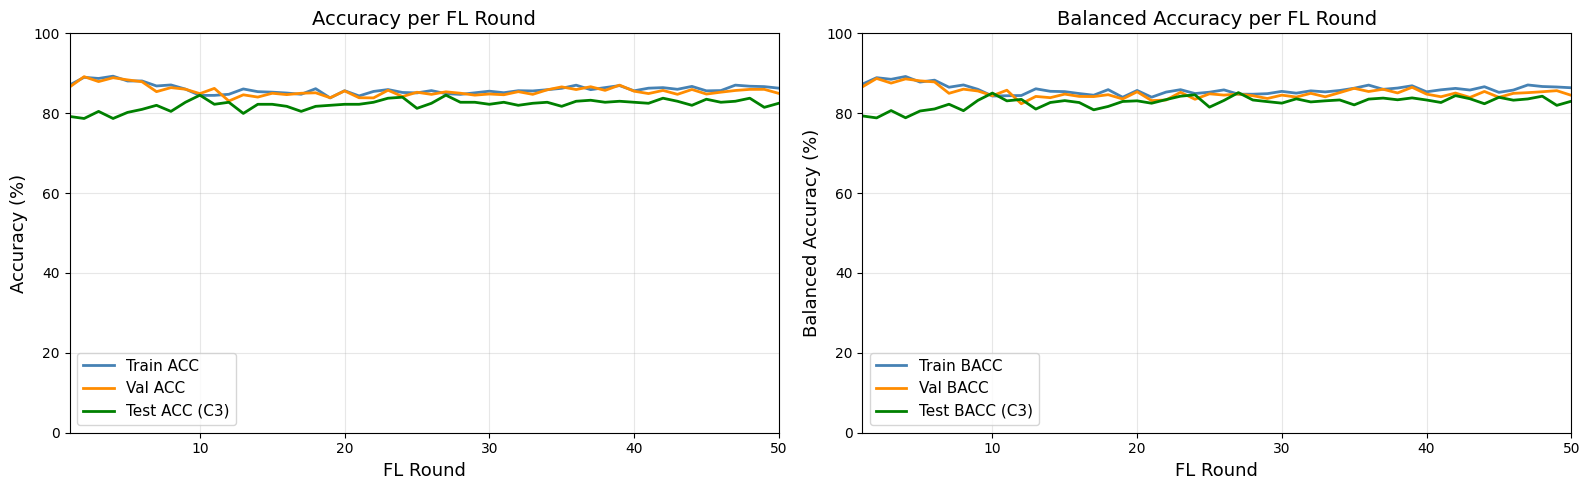

Plot saved to /content/drive/MyDrive/FACMIC/outputs_aug_data/training_curves.png


In [19]:
import matplotlib.pyplot as plt

rounds = history["rounds"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── ACC plot ──────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(rounds, history["train_acc"], label="Train ACC",  color="steelblue",  linewidth=2)
ax.plot(rounds, history["val_acc"],   label="Val ACC",    color="darkorange",  linewidth=2)
ax.plot(rounds, history["test_acc"],  label="Test ACC (C3)", color="green",   linewidth=2)
ax.set_xlabel("FL Round", fontsize=13)
ax.set_ylabel("Accuracy (%)", fontsize=13)
ax.set_title("Accuracy per FL Round", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, ROUNDS)
ax.set_ylim(0, 100)

# ── BACC plot ─────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(rounds, history["train_bacc"], label="Train BACC",     color="steelblue",  linewidth=2)
ax.plot(rounds, history["val_bacc"],   label="Val BACC",       color="darkorange",  linewidth=2)
ax.plot(rounds, history["test_bacc"],  label="Test BACC (C3)", color="green",       linewidth=2)
ax.set_xlabel("FL Round", fontsize=13)
ax.set_ylabel("Balanced Accuracy (%)", fontsize=13)
ax.set_title("Balanced Accuracy per FL Round", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, ROUNDS)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved to {OUTPUT_DIR}/training_curves.png")

In [20]:
# Load best checkpoint
global_attention.load_state_dict(
    torch.load(f"{OUTPUT_DIR}/best_attention.pt", map_location=device)
)

print("=" * 55)
print("  Final Results — best checkpoint on client_3 test set")
print("=" * 55)
acc, bacc = evaluate(global_attention, test_loader)
print(f"  Test  ACC  = {acc:.2f}%")
print(f"  Test  BACC = {bacc:.2f}%")

print("\n  Validation on training clients:")
for cid, vl in enumerate(val_loaders):
    vacc, vbacc = evaluate(global_attention, vl)
    print(f"    client_{cid}  ACC={vacc:.2f}%  BACC={vbacc:.2f}%")

# Best round from history
best_round = history["rounds"][
    int(np.argmax(history["test_acc"]))
]
print(f"\n  Best test ACC achieved at round {best_round}")

  Final Results — best checkpoint on client_3 test set
  Test  ACC  = 84.52%
  Test  BACC = 85.04%

  Validation on training clients:
    client_0  ACC=84.85%  BACC=84.43%
    client_1  ACC=84.09%  BACC=82.78%
    client_2  ACC=89.53%  BACC=89.24%

  Best test ACC achieved at round 10
